In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
results_dir = '/nesi/project/niwa00015/queenle/results/'

result_dfs = {'HadGEM3':pd.read_csv(results_dir + 'HadGEM3_PM_results_final.csv'),
              'ECHAM5':pd.read_csv(results_dir + 'ECHAM5_PM_results_final.csv'),
              'd4PDF':pd.read_csv(results_dir + 'd4PDF_PM_results_final.csv')}

def check_sizes(df):
    if len(df['HadGEM3']) != 5400:
        print('HadGEM3 wrong size: ' + str(len(df['HadGEM3'])))
        
    if len(df['ECHAM5']) != 108000:
        print('ECHAM5 wrong size: ' + str(len(df['ECHAM5'])))
    
    if len(df['d4PDF']) != 342000:
        print('d4PDF wrong size')
        
check_sizes(result_dfs)

In [13]:
var_dict = {'ECHAM5':['tas','pr','mrro'],
            'HadGEM3':['tas','pr'],
            'd4PDF':['TA','PRECIPI','ROF']}

trunc_dict = {'HadGEM3':10,
              'ECHAM5':36,
              'd4PDF':60}

color_dict = {'HadGEM3':'blue',
              'ECHAM5':'orange',
              'd4PDF':'green'}

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

In [14]:
def get_percentage_of_detectability(df, var, trunc, season, time_step):
    
    summary_df = df.query('variable==\''+var+'\' and trunc==\''+str(trunc)+'\' and season==\''+season+'\' and time_step==\''+time_step+'\'')

    percent_detectable = len(summary_df[summary_df['ant_lower']>0])/len(summary_df)
    
    return(percent_detectable*100)
    

In [15]:
def plot_histogram(ax,model_i,model,season,var,trunc,df,c):

    y_vals = []
    for time_step in ['annual','5Y','10Y']:
        percent = get_percentage_of_detectability(df,var,trunc,season,time_step)
        
        y_vals.append(percent)
        
    x_vals = [3*model_i+j+model_i for j in range(3)]
    ax.bar(x_vals,y_vals,color=c,label=model)


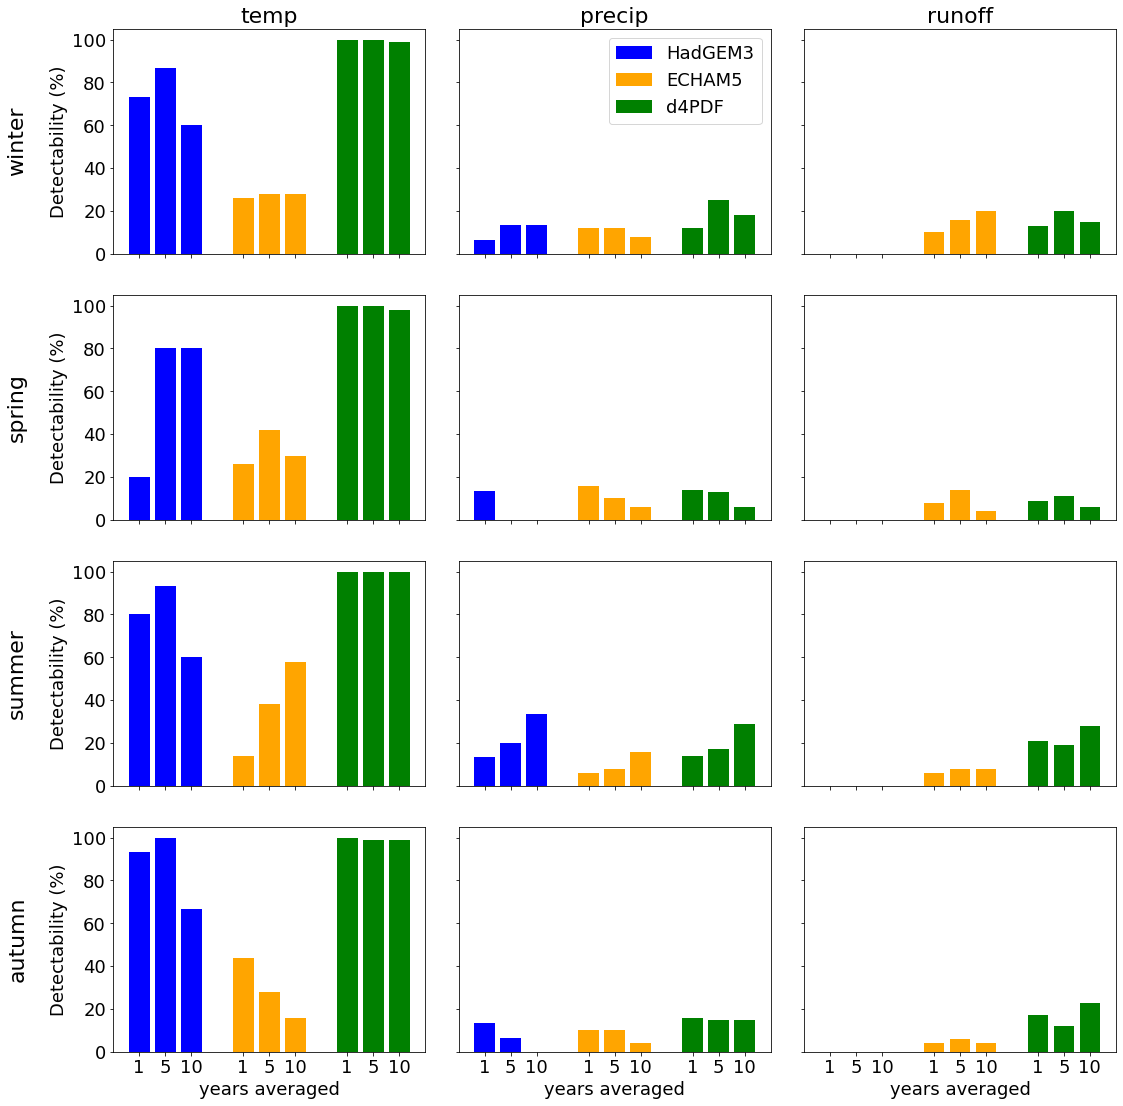

In [16]:

fig,axs = plt.subplots(4,3,figsize=(16,16),sharey=True,sharex=True)

for i,season in enumerate(['winter','spring','summer','autumn']):
    
    for j,variable in enumerate(['temp','precip','runoff']):
        
        model_i = 0
        for model in ['HadGEM3','ECHAM5','d4PDF']:
            
            df = result_dfs[model]
            trunc = trunc_dict[model]
            
            try:
                plot_histogram(axs[i][j],model_i,model,season,var_dict[model][j],trunc,df,color_dict[model])
            except:
                model_i += 1
                continue
                
            model_i += 1
            
        axs[i][j].set_xlim(-1,11)
        axs[i][j].set_ylim(0,105)

        if i == 0 and j == 1:
            axs[i][j].legend(fontsize=18)
            
        if i == 0:
            axs[i][j].set_title(variable,fontdict=font)
            
        if i == 3:
            font['size']=18
            axs[i][j].set_xticks([0,1,2,4,5,6,8,9,10])
            axs[i][j].set_xticklabels(['1','5','10','1','5','10','1','5','10'],fontdict=font)
            axs[i][j].set_xlabel('years averaged',fontdict=font)
            font['size']=22
            
            
            
        if j == 0:
            font['size']=18
            axs[i][j].set_yticks([0,20,40,60,80,100])
            axs[i][j].set_yticklabels(['0','20','40','60','80','100'],fontdict=font)
            axs[i][j].set_ylabel('Detectability (%)',fontdict=font)
            font['size']=22
            
            axs[i][j].text(-0.34,.5,season,transform=axs[i][j].transAxes,fontdict=font,rotation='vertical',va='center')
        
plt.tight_layout(pad=3)
fig.patch.set_alpha(1) 

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/time_steps_figure_tas.png',dpi=300)
